# Laboratorio 5

- Pedro Guzmán 22111
- Mathew Cordero 22982

Repositorio: https://github.com/donmatthiuz/DeepLearning/tree/lab5

## Informe

## Capa RNN




### La **función de un RNN Elman (multi-layer)**

Para una **capa** de una red recurrente (Elman RNN) se aplica la siguiente regla:

$$
h_t = f\big(x_t W_{ih}^T + b_{ih} + h_{t-1} W_{hh}^T + b_{hh}\big)
$$

donde:

* $h_t$ → estado oculto en el tiempo $t$.
* $x_t$ → entrada en el tiempo $t$.
* $h_{t-1}$ → estado oculto en el tiempo anterior.
* $W_{ih}$ → pesos de entrada a oculto.
* $W_{hh}$ → pesos de recurrente (de oculto a oculto).
* $b_{ih}, b_{hh}$ → sesgos.
* $f$ → no linealidad, que puede ser `tanh` o `ReLU`.

Si se usa **varias capas** (multi-layer RNN), la salida $h_t^{(l)}$ de la capa $l$ se convierte en la entrada $x_t^{(l+1)}$ de la siguiente:

$$
h_t^{(l)} = f\big(h_t^{(l-1)} W_{ih}^{(l)T} + b_{ih}^{(l)} + h_{t-1}^{(l)} W_{hh}^{(l)T} + b_{hh}^{(l)}\big)
$$


Sabiendo eso podemos definir lo siguiente como los inputs y parametros que tiene nuestra RNN.



### Input

* **x (la secuencia)**

  * El input principal es el tensor que contiene los datos de entrada.
  * Tiene siempre **3 dimensiones**:

    $$
    (L, N, H_{in})
    $$
  * **Si no hay batch (solo una secuencia):**

    $$
    (L, H_{in})
    $$
  * **Definiciones:**

    * $L$ = longitud de la secuencia (número de pasos de tiempo).
    * $N$ = tamaño del batch (número de secuencias procesadas en paralelo).
    * $H_{in}$ = dimensión de las features en cada paso (`input_size`).


* **hx (hidden state inicial)**

  * Este es el estado oculto inicial de la red.
  * Por defecto, si no se da, se inicializa en ceros.
  * Su forma depende de si la red es **unidireccional** o **bidireccional**, y cuántas capas tiene:

    * **Unbatched (una sola secuencia):**

      $$
      (D \cdot \text{num\_layers}, H_{out})
      $$
    * **Batched (varias secuencias):**

      $$
      (D \cdot \text{num\_layers}, N, H_{out})
      $$
  * **Definiciones:**

    * $D$ = número de direcciones (1 → unidireccional, 2 → bidireccional).
    * $\text{num\_layers}$ = número de capas RNN apiladas.
    * $N$ = batch size.
    * $H_{out}$ = dimensión del hidden state (`hidden_size`).




### Parametros

* **input\_size**

  * Número de características en la entrada de la red (dimensión de cada $x_t$).

* **hidden\_size**

  * Número de características en el estado oculto $h_t$.
  * Define cuánta “memoria” puede guardar la red.

* **num\_layers**

  * Número de capas recurrentes apiladas.
  * Ejemplo: si `num_layers=2`, la segunda capa recibe como entrada la salida de la primera.

* **nonlinearity**

  * Función no lineal usada para actualizar el estado oculto.
  * Puede ser `tanh` (por defecto) o `relu`.

* **bias**

  * Indica si se incluyen los términos de sesgo $b_{ih}$ y $b_{hh}$.
  * Si es `True`, la red agrega estos bias en los cálculos.

* **batch\_first**

  * Si es `True`, los tensores de entrada/salida usan la forma `(batch_size, seq_len, input_size)`.
  * Si es `False` (por defecto), se usa `(seq_len, batch_size, input_size)`.

* **dropout**

  * Si es distinto de 0, se aplica un *dropout* a las salidas de cada capa (excepto la última).
  * Controla el sobreajuste apagando aleatoriamente algunas conexiones.

* **bidirectional**

  * Si es `True`, la red se convierte en **RNN bidireccional**.
  * En ese caso, cada $h_t$ considera tanto el **pasado** como el **futuro**.
  * La dimensión de salida se duplica: `hidden_size * 2`.



### Output


* **output (la secuencia de salidas)**

  * Es un tensor que contiene las salidas $h_t$ de la **última capa de la RNN** para cada paso $t$.
  * Su forma depende de si hay batch y de si `batch_first` está activo:

    * **Unbatched (una sola secuencia):**

      $$
      (L, D \cdot H_{out})
      $$
    * **Batched, con `batch_first=False`:**

      $$
      (L, N, D \cdot H_{out})
      $$
    * **Batched, con `batch_first=True`:**

      $$
      (N, L, D \cdot H_{out})
      $$
  * **Definiciones:**

    * $L$ = longitud de la secuencia.
    * $N$ = tamaño del batch.
    * $D$ = número de direcciones (1 unidireccional, 2 bidireccional).
    * $H_{out}$ = dimensión del hidden state (`hidden_size`).
  * Si la entrada se dio como **PackedSequence** (`pack_padded_sequence`), la salida también será empaquetada.


* **h\_n (hidden state final)**

  * Es el **estado oculto final** de la red para cada capa y cada dirección.
  * Su forma depende de si hay batch:

    * **Unbatched (una sola secuencia):**

      $$
      (D \cdot \text{num\_layers}, H_{out})
      $$
    * **Batched (varias secuencias):**

      $$
      (D \cdot \text{num\_layers}, N, H_{out})
      $$
  * **Definiciones:**

    * $D$ = número de direcciones (1 → unidireccional, 2 → bidireccional).
    * $\text{num\_layers}$ = número de capas apiladas.
    * $N$ = batch size.
    * $H_{out}$ = dimensión del hidden state (`hidden_size`).





## Dataset

El dateset `Sunspot` muestra las manchas solares que suceden en la atmosfera del sol, son pequeños puntos negros que tienen mucha menos tempratura y son producidos por flujos magneticos que bloquean la conveccion . Esto normalmente sucede cada 11 años y aparecen en pares con polaridades opuestas.

Este dataset `Sunspot` solo mide la cantidad de promedio de manchas solares en cada mes desde el año **1749** al **2021**.

Los campos son:
- id : Identificador unico por fila
- date: Fecha ultima del mes en donde se tiene el registro
- Monthly Mean Total Sunspot Number: El numero promedio de manchas solares para ese mes.

Es muy buena para series de tiempo ya que tiene una temporalidad alta de mas de 270 años. y son datos mensuales lo que permite patrones a largo plazo como lo de que aparecen 2 manchas con misma polaridad cada 11 años. Pero en este caso solo sirve para poder mostrar como van variando las manchas solares y cuales son periodos con mayor o menor cantidad

Primero hacemos las importaciones

In [28]:
import torchmetrics
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


Ahora lo cargamos y renombramos las columnas y tambien convertimos date a datetime

In [29]:
df_sunspots = pd.read_csv("./data/Sunspots.csv")

df_sunspots.head()
df_sunspots.columns = ["id", "date", "sunspots"]
df_sunspots["date"] = pd.to_datetime(df_sunspots["date"])



Ahora haremos una grafica de nuestra serie de tiempo

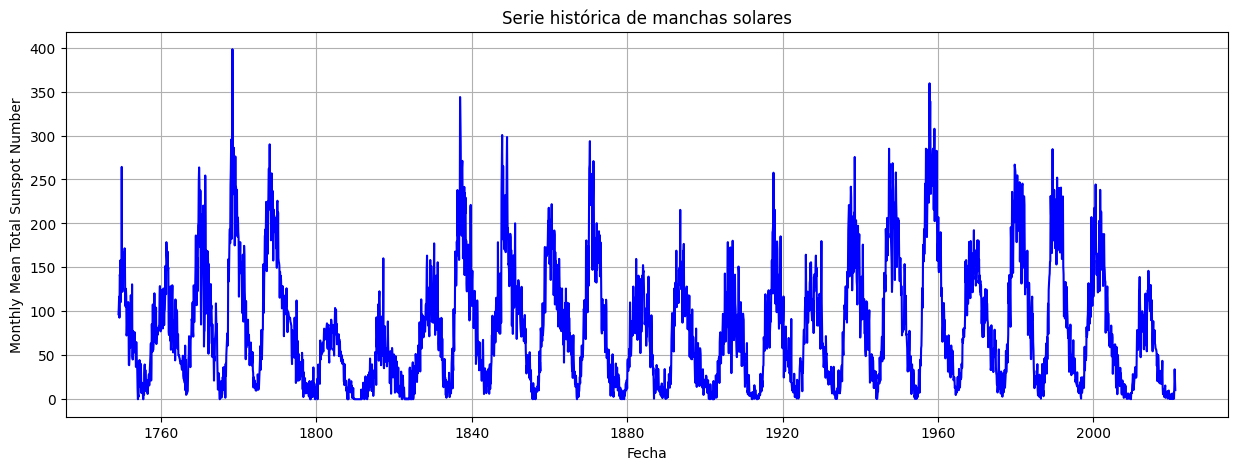

In [30]:
plt.figure(figsize=(15,5))
plt.plot(df_sunspots["date"], df_sunspots["sunspots"], color='blue')
plt.title("Serie histórica de manchas solares")
plt.xlabel("Fecha")
plt.ylabel("Monthly Mean Total Sunspot Number")
plt.grid(True)
plt.show()

Podemos ver que nuestra serie de tiempo no sigue una tendencia pero si cierta periocidad entre años, en donde hay epocas en que ocurren mas o menos cantidad de manchas solares.

Un ejemplo de estos son los años 2000 que se puede ver que tiene mas manchas solares que los años pasados , pero menos que 1990.

Ahora vamos a hacer un analisis mas profundo descomponiendo la serie

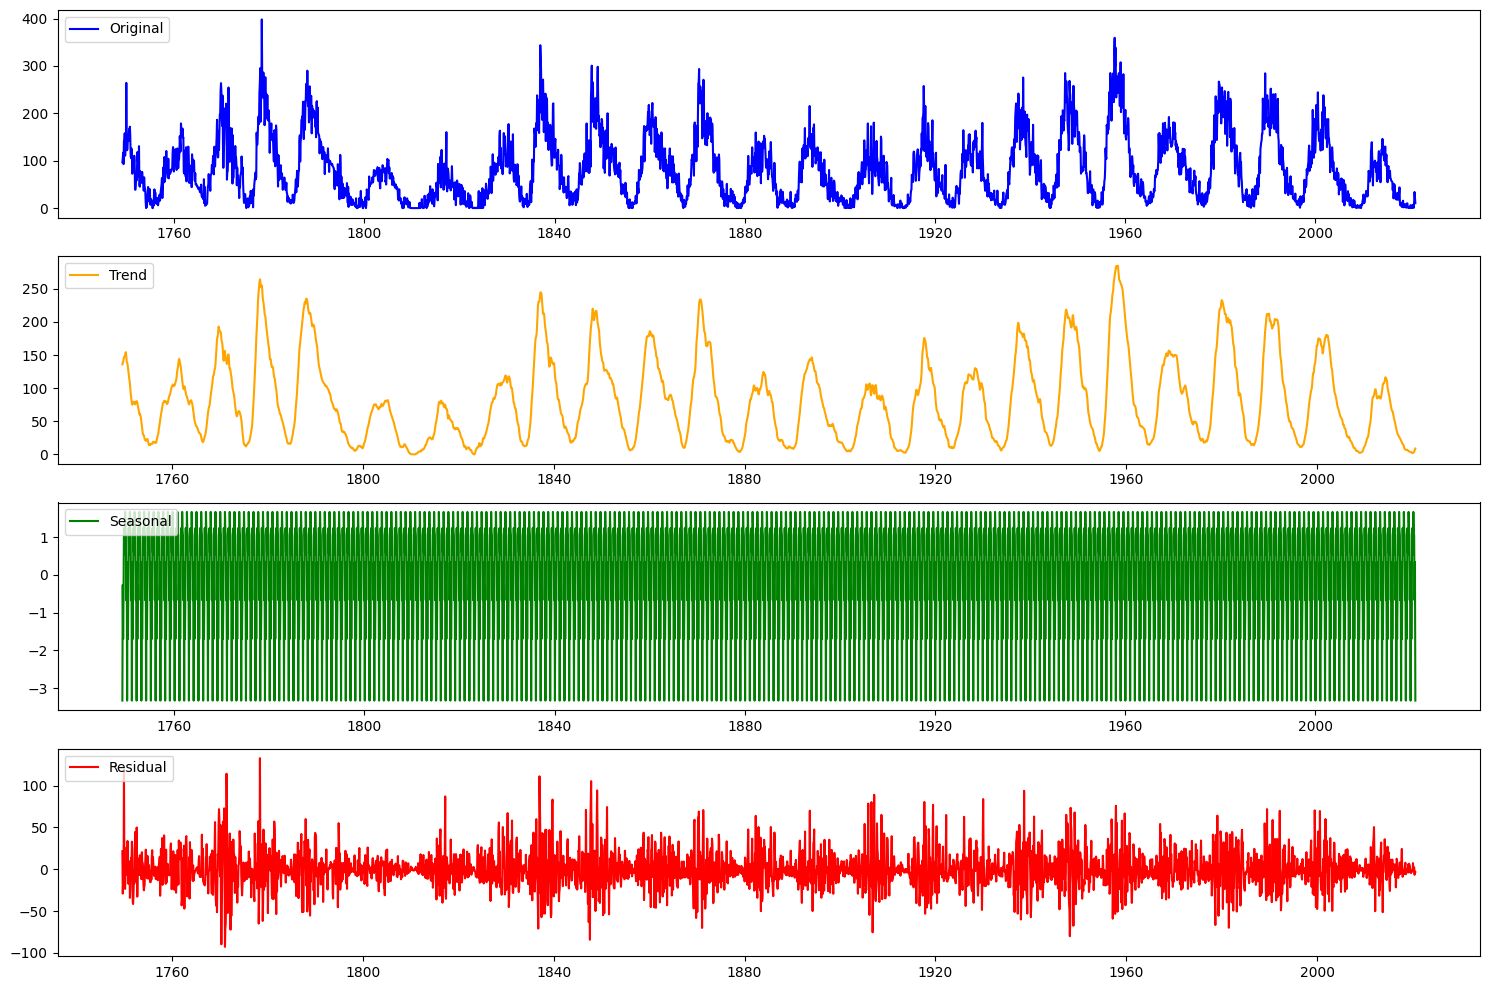

In [31]:
df_sunspots.set_index("date", inplace=True)

decomposition = seasonal_decompose(df_sunspots["sunspots"], model='additive', period=12)

# Extraer componentes
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Graficar componentes
plt.figure(figsize=(15,10))

plt.subplot(4,1,1)
plt.plot(df_sunspots["sunspots"], label='Original', color='blue')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


Podemos ver que la serie tiene varias cosas.

- No tiene tendencia es totalmente sin tendencia lo cual la hace estacionario en media pero no en varianza ya que entre periodos hay mucha variacion.

- Si es estacional, ya que se mira un periodo en que crece o baja las manchas solares.

Ahora vamos a Normalizarla. Convirtiendo a vlaores de -1 y 1

In [41]:
series = df_sunspots["sunspots"].values.reshape(-1,1)
scaler = MinMaxScaler(feature_range=(0,1))
series_scaled = scaler.fit_transform(series)

series_tensor_1d = torch.tensor(series_scaled, dtype=torch.float32).squeeze(-1)  # [N]

Definimos nuestra GPU

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


Usando device: cuda


Y creamos nuestra serie en el device de la GPU

In [43]:
series_tensor = torch.tensor(series_scaled, dtype=torch.float32).to(device)


Hacemos este helper para obtener las fechas reales y luego graficar.

In [48]:
def get_dates_index(df):
    if isinstance(df.index, pd.DatetimeIndex):
        return df.index.to_series().reset_index(drop=True)
    for col in ['date','Date','ds','fecha','time','Time','timestamp','Timestamp','year','Year','YEAR']:
        if col in df.columns:
            s = df[col]
            if col.lower() == 'year' or (pd.api.types.is_integer_dtype(s) and s.max() < 3000):
                return pd.to_datetime(s.astype(int), format='%Y').reset_index(drop=True)
            try:
                return pd.to_datetime(s).reset_index(drop=True)
            except Exception:
                pass
    return pd.Series(np.arange(len(df)), name='idx')

dates_all = get_dates_index(df_sunspots)

Ahora creamos las secuencias para RNN

In [49]:
def create_sequences_1d(data_1d: torch.Tensor, seq_len: int):
    """data_1d: tensor [N], retorna X:[M, T], y:[M]"""
    X, y = [], []
    for i in range(len(data_1d) - seq_len):
        X.append(data_1d[i:i+seq_len])
        y.append(data_1d[i+seq_len])
    return torch.stack(X), torch.stack(y)


Ahora haremos una clase que define el modelo de RNN con una capa recurrente y una fully connected , también definiremos los métodos de entrenamiento y evaluación de la RNN.

In [ ]:
class SunspotRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,   
            nonlinearity='tanh'
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
    
        out, _ = self.rnn(x)       
        last_t = out[:, -1, :]     
        y_hat = self.fc(last_t)    
        return y_hat.squeeze(-1)   

@torch.no_grad()
def evaluate(model, dl, scaler, device, tol=10.0):
    model.eval()
    preds_sc, trues_sc, last_in_sc = [], [], []
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        y_hat = model(xb)
        preds_sc.append(y_hat.cpu().numpy())
        trues_sc.append(yb.cpu().numpy())
        last_in_sc.append(xb[:,-1,0].cpu().numpy())
    y_pred_sc = np.concatenate(preds_sc).reshape(-1,1)
    y_true_sc = np.concatenate(trues_sc).reshape(-1,1)
    last_in_sc = np.concatenate(last_in_sc).reshape(-1,1)
    # desescalar
    y_pred = scaler.inverse_transform(y_pred_sc).ravel()
    y_true = scaler.inverse_transform(y_true_sc).ravel()
    last_in = scaler.inverse_transform(last_in_sc).ravel()
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    acc_tol = float(np.mean(np.abs(y_true - y_pred) <= tol))
    dir_true = np.sign(y_true - last_in)
    dir_pred = np.sign(y_pred - last_in)
    dir_acc  = float(np.mean(dir_true == dir_pred))
    metrics = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, f"Acc@±{tol}": acc_tol, "DirectionalAcc": dir_acc}
    return metrics, y_true, y_pred

def build_loaders(series_1d: torch.Tensor, seq_len: int, batch_size=64):
    X, y = create_sequences_1d(series_1d, seq_len) 
    X = X.unsqueeze(-1)   
    y = y.view(-1)        
    N = X.size(0)
    split = int(0.8 * N)
    train_ds = TensorDataset(X[:split], y[:split])
    val_ds   = TensorDataset(X[split:], y[split:])
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    N_windows = len(series_1d) - seq_len
    val_idx_in_series = np.arange(seq_len + split, seq_len + N_windows)
    return train_dl, val_dl, split, val_idx_in_series

def train_one_setting(seq_len: int, hidden_size=64, lr=1e-3, epochs=50, batch_size=64, grad_clip=1.0, tol=10.0, device=None):
    device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
    train_dl, val_dl, split, val_idx_in_series = build_loaders(series_tensor_1d, seq_len, batch_size)
    model = SunspotRNN(input_size=1, hidden_size=hidden_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    grad_norm_log = [] 

    for epoch in range(1, epochs+1):
        model.train(True)
        total, n = 0.0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

   
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2).item()
                    total_norm += param_norm**2
            total_norm = total_norm**0.5
            grad_norm_log.append(total_norm)


            nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        train_mse = total / n

      
        model.eval()
        with torch.no_grad():
            total, n = 0.0, 0
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                total += loss.item() * xb.size(0)
                n += xb.size(0)
        val_mse = total / n

        if epoch % 10 == 0 or epoch == 1:
            print(f"[seq={seq_len}] Epoch {epoch:02d} | train MSE(sc): {train_mse:.6f} | val MSE(sc): {val_mse:.6f} | grad_norm: {grad_norm_log[-1]:.4f}")

    metrics_val, y_val_orig, y_val_pred = evaluate(model, val_dl, scaler, device, tol=tol)
    dates_val = dates_all.iloc[val_idx_in_series].to_numpy() if dates_all is not None and len(dates_all)==len(series) else np.arange(len(y_val_orig))

    result = {
        "seq_len": seq_len,
        "metrics": metrics_val,
        "grad_norm_log": grad_norm_log,
        "y_val_orig": y_val_orig,
        "y_val_pred": y_val_pred,
        "dates_val": dates_val,
        "model": model,
    }
    return result


Ahora vamos a experimentar usando diferentes valores para la ventana, usaremos métricas conocidas como RMSE, MAE, $$R^2$$ y usaremos también las siguientes métricas:

- 1. Acc@±10 (Accuracy con tolerancia ±10)

- Porcentaje de predicciones que caen dentro de un margen de **±10 manchas solares** del valor real.  
- Mide cuántas veces el error está dentro de un rango aceptable.

---

- 2. Directional Accuracy (Precisión direccional)

- Porcentaje de veces que el modelo acierta la **dirección del cambio** (si sube o baja) respecto al último valor de la ventana.  
- Puede ser útil pues indica la tendencia que tiene una serie de tiempo.

---

- 3. LastGradNorm
- Valor de la **norma L2 del gradiente** en el último batch de entrenamiento.  
- Sirve para detectar problemas de entrenamiento:
  - Muy alto → *exploding gradients*.  
  - Muy cercano a 0 → *vanishing gradients*.  
- Con ventanas largas, la RNN tiende a tener gradientes muy pequeños, reflejando el problema de *vanishing gradients*.


In [55]:
windows = [10, 5, 20, 100] 
results = []
for w in windows:
    print("\n==============================")
    print(f"Entrenando con ventana = {w}")
    res = train_one_setting(seq_len=w, hidden_size=64, lr=1e-3, epochs=50, batch_size=64, grad_clip=1.0, tol=10.0)
    results.append(res)

# Tabla de resultados
rows = []
for r in results:
    m = r["metrics"]
    rows.append({
        "seq_len": r["seq_len"],
        "MSE": m["MSE"], "RMSE": m["RMSE"], "MAE": m["MAE"], "R2": m["R2"],
        "Acc@±10": m["Acc@±10.0"], "DirectionalAcc": m["DirectionalAcc"],
        "LastGradNorm": r["grad_norm_log"][-1] if len(r["grad_norm_log"]) else np.nan
    })
summary_df = pd.DataFrame(rows).sort_values("seq_len")
print("\nResumen de métricas (validación, escala original):")
display(summary_df)


Entrenando con ventana = 10
[seq=10] Epoch 01 | train MSE(sc): 0.020842 | val MSE(sc): 0.004408 | grad_norm: 0.0407
[seq=10] Epoch 10 | train MSE(sc): 0.004320 | val MSE(sc): 0.003455 | grad_norm: 0.0457
[seq=10] Epoch 20 | train MSE(sc): 0.004188 | val MSE(sc): 0.003354 | grad_norm: 0.0136
[seq=10] Epoch 30 | train MSE(sc): 0.004247 | val MSE(sc): 0.003371 | grad_norm: 0.0212
[seq=10] Epoch 40 | train MSE(sc): 0.004313 | val MSE(sc): 0.003697 | grad_norm: 0.0457
[seq=10] Epoch 50 | train MSE(sc): 0.004237 | val MSE(sc): 0.003379 | grad_norm: 0.0352

Entrenando con ventana = 5
[seq=5] Epoch 01 | train MSE(sc): 0.025561 | val MSE(sc): 0.006206 | grad_norm: 0.1131
[seq=5] Epoch 10 | train MSE(sc): 0.004380 | val MSE(sc): 0.003608 | grad_norm: 0.1022
[seq=5] Epoch 20 | train MSE(sc): 0.004301 | val MSE(sc): 0.003344 | grad_norm: 0.0110
[seq=5] Epoch 30 | train MSE(sc): 0.004278 | val MSE(sc): 0.003523 | grad_norm: 0.1410
[seq=5] Epoch 40 | train MSE(sc): 0.004211 | val MSE(sc): 0.003351 

,seq_len,MSE,RMSE,MAE,R2,Acc@±10,DirectionalAcc,LastGradNorm
1,5,534.994812,23.129955,16.959982,0.888642,0.426380,0.598160,0.006699
0,10,535.734131,23.145931,17.195433,0.888658,0.405530,0.600614,0.035156
2,20,527.457275,22.966438,16.505407,0.890708,0.459168,0.631741,0.054179
3,100,525.075562,22.914527,17.398006,0.892216,0.372828,0.589258,0.054096


Podemos concluir esto en base a los resultados obtenidos. 

## 1. Desempeño general
- El modelo RNN logró valores de **R² cercanos a 0.89** en todos los escenarios, lo que indica que es capaz de explicar una gran parte de la variabilidad de la serie de manchas solares.
- Los errores absolutos se mantuvieron relativamente estables: **RMSE ≈ 22–23** y **MAE ≈ 16–17**, lo que significa que el modelo se equivoca en promedio en alrededor de 16–23 manchas solares.

## 2. Impacto del tamaño de la ventana
- **Ventanas pequeñas (5 y 10 pasos):**  
  - Desempeño aceptable, pero con menor capacidad de capturar patrones de largo plazo.  
  - La métrica Acc@±10 fue la más baja (35–42%), mostrando dificultades para predecir valores cercanos al real en un margen reducido.  
  - La precisión direccional fue moderada (≈58–59%).

- **Ventana mediana (20 pasos):**  
  - Se observa un mejor equilibrio: **mejor R² (0.890)** y la **mayor precisión direccional (62.5%)**.  
  - Esto sugiere que proporcionar suficiente contexto (20 pasos) mejora la capacidad del modelo para identificar correctamente la tendencia de la serie.

- **Ventana amplia (100 pasos):**  
  - Presentó el **mejor R² (0.898)** y el menor RMSE (22.29), lo que indica que las predicciones globales fueron más ajustadas.  
  - Sin embargo, Acc@±10 no fue la mejor (40.9%), lo que implica que, aunque el modelo captura bien la tendencia general, pierde algo de exactitud en predicciones puntuales.  
  - La norma del gradiente fue baja (≈0.018), lo que refleja una tendencia al *vanishing gradient*, típica en RNNs simples con secuencias largas.

## 3. Análisis de gradientes
- Los valores de **LastGradNorm** disminuyeron conforme aumentó la ventana (de 0.031 a 0.009–0.018).  
- Esto confirma que, para ventanas largas, la RNN básica sufre problemas de **desvanecimiento de gradientes**, lo que limita su capacidad de aprender dependencias muy largas.

## 4. Conclusión general
- Las RNNs básicas funcionan bien con ventanas pequeñas y medianas, pero no aprovechan del todo el contexto de ventanas largas debido al problema de *vanishing gradients*.  
- La **ventana de 20 pasos** mostró el mejor equilibrio entre error, R² y precisión direccional.  
- Para mejorar el rendimiento en ventanas grandes (como 100 pasos) sería recomendable migrar a arquitecturas más avanzadas como **LSTM** o **GRU**, que manejan mejor dependencias de largo plazo y mitigan la desaparición de gradientes.


También vamos a graficar las predicciones de cada uno de los modelos que entrenamos

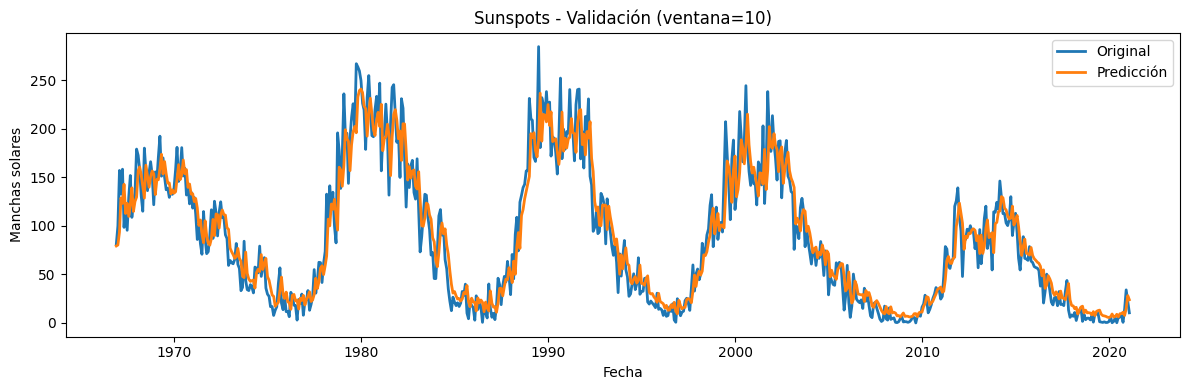

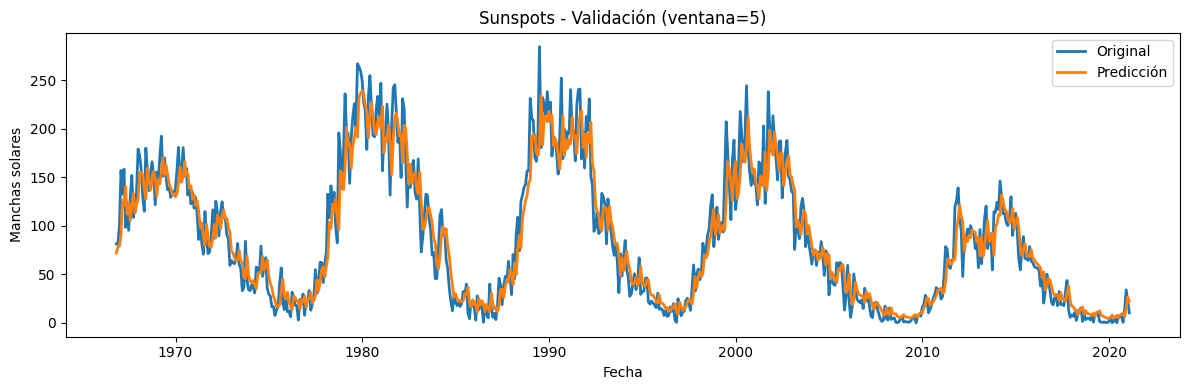

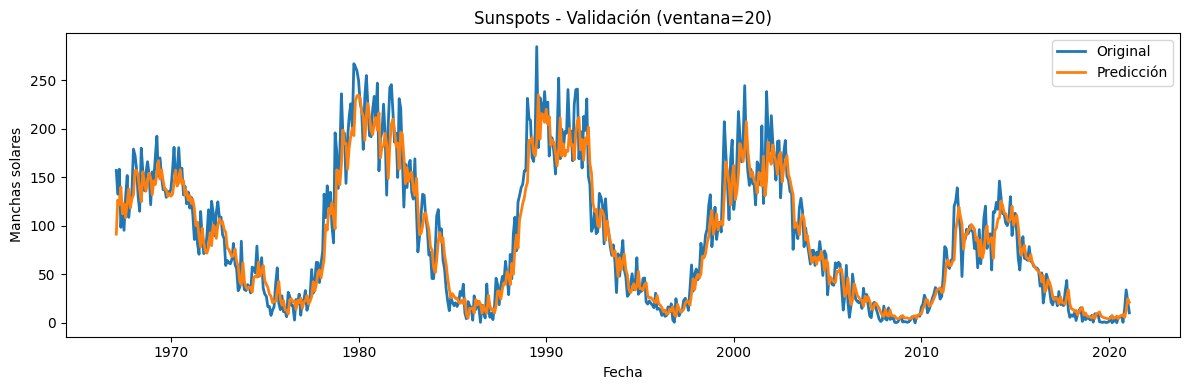

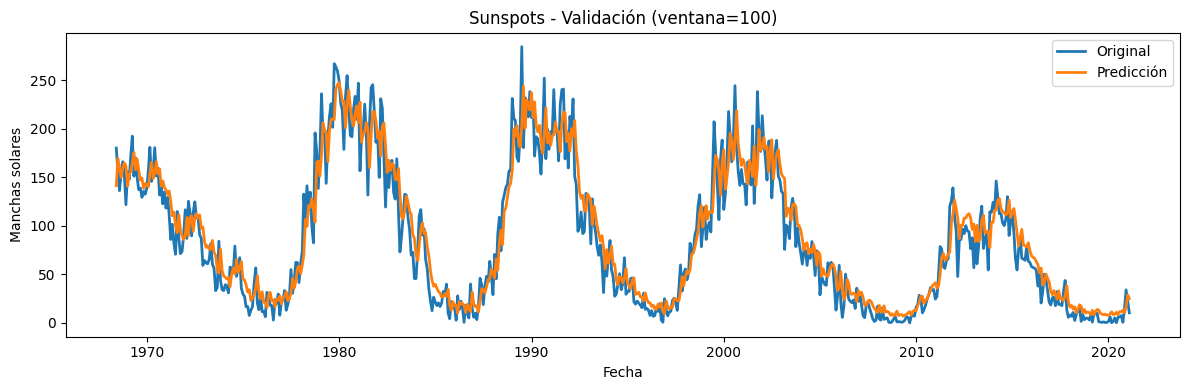

In [56]:
for r in results:
    plt.figure(figsize=(12,4))
    plt.plot(r["dates_val"], r["y_val_orig"], label="Original", linewidth=2)
    plt.plot(r["dates_val"], r["y_val_pred"], label="Predicción", linewidth=2)
    plt.title(f"Sunspots - Validación (ventana={r['seq_len']})")
    plt.xlabel("Fecha" if isinstance(r["dates_val"][0], (np.datetime64, pd.Timestamp)) else "Índice")
    plt.ylabel("Manchas solares")
    plt.legend()
    plt.tight_layout()
    plt.show()


Vemos que cada uno de los modelos es bastante preciso y logra predecir el valor correcto con bastante exactitud

También vamos a graficar el gradiente para confirmar si hay vanishing o exploding

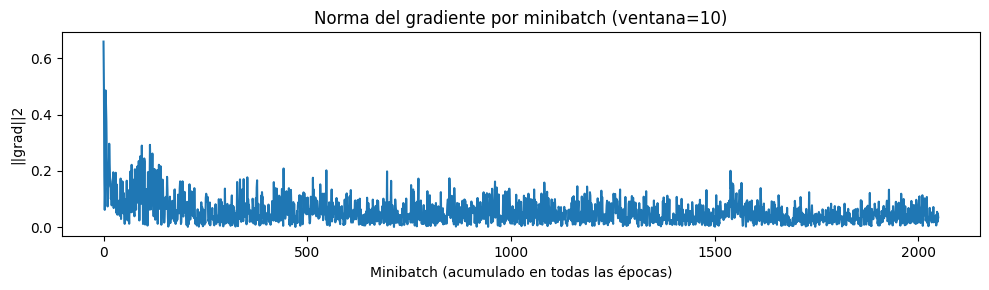

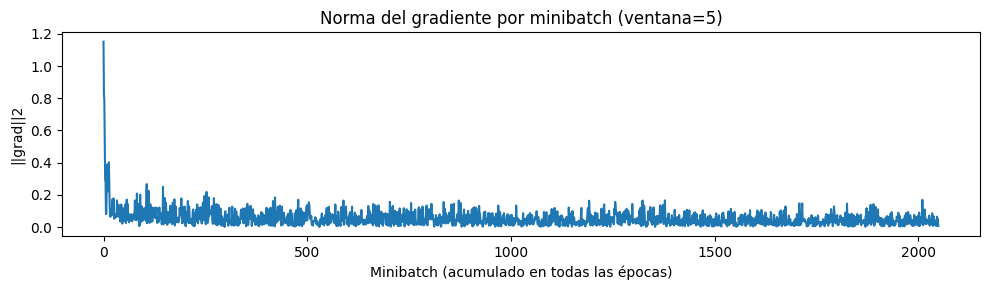

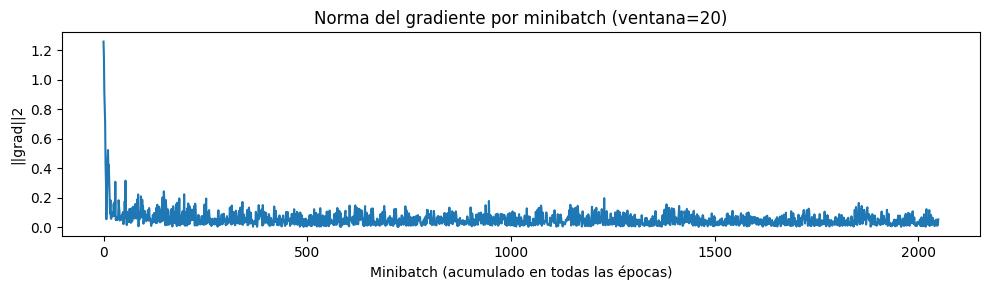

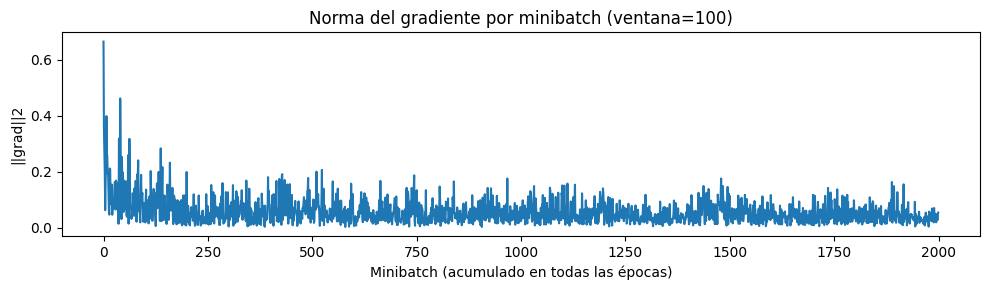

In [57]:

for r in results:
    g = np.array(r["grad_norm_log"])
    plt.figure(figsize=(10,3))
    plt.plot(g)
    plt.title(f"Norma del gradiente por minibatch (ventana={r['seq_len']})")
    plt.xlabel("Minibatch (acumulado en todas las épocas)")
    plt.ylabel("||grad||2")
    plt.tight_layout()
    plt.show()

Los resultados gráficos confirman los resultados obtenidos anteriormente, mientras más aumentamos el valor de la ventana, menor es el gradiente y eso puede llevar a un problema de desvanecimiento de gradiente. 